In [1]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing 
from statsmodels.tsa.holtwinters import Holt 
import pandas as pd
import numpy as np
import os
import sys


In [2]:
df = pd.read_csv("/Applications/Work Space/Python Work Space/python_forcesting/airline_passengers.csv", index_col="Month", parse_dates=True)
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [3]:
df.index.freq = "MS" # Calendar mounth begin...

In [4]:
holt = Holt(df["Passengers"], initialization_method="legacy-heuristic")

In [5]:
res_h = holt.fit()

In [6]:
df["Holt"] = res_h.fittedvalues

<Axes: xlabel='Month'>

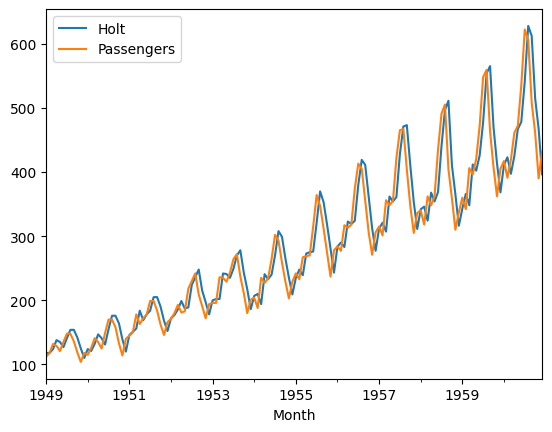

In [7]:
df[["Holt", "Passengers"]].plot()

<Axes: xlabel='Month'>

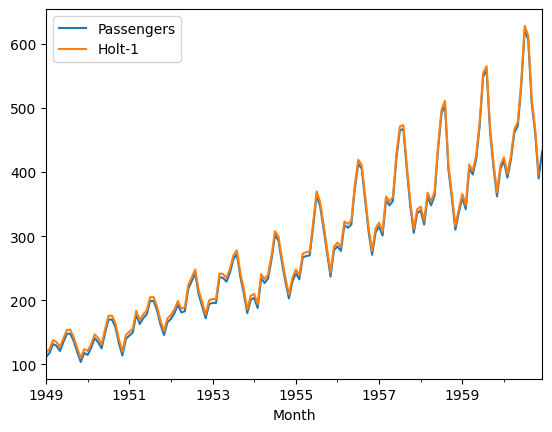

In [8]:
## No!

df["Holt-1"] = df["Holt"].shift(-1)

df[["Passengers", "Holt-1"]].plot()

In [9]:
N_test = 12
train = df.iloc[:-N_test]
test = df.iloc[-N_test:]

In [10]:
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [11]:
df

,Passengers,Holt,Holt-1
Month,,,
1949-01-01,112,118.000000,118.029403
1949-02-01,118,118.029403,123.999547
1949-03-01,132,123.999547,137.960194
1949-04-01,129,137.960194,135.044106
1949-05-01,121,135.044106,127.068128
...,...,...,...
1960-08-01,606,627.561287,612.073575
1960-09-01,508,612.073575,514.475781
1960-10-01,461,514.475781,467.217472


In [ ]:
holt_train = Holt(train["Passengers"], initialization_method="legacy-heuristic")
res_h_train =  holt_train.fit()
df.loc[train_idx, "Holt_1"] = res_h_train.fittedvalues
df.loc[test_idx, "Holt_1"] = res_h_train.forecast(N_test)
df

,Passengers,Holt,Holt-1,Holt_1
Month,,,,
1949-01-01,112,118.000000,118.029403,118.000000
1949-02-01,118,118.029403,123.999547,118.002177
1949-03-01,132,123.999547,137.960194,123.972314
1949-04-01,129,137.960194,135.044106,137.969391
1949-05-01,121,135.044106,127.068128,135.012601
...,...,...,...,...
1960-08-01,606,627.561287,612.073575,438.840643
1960-09-01,508,612.073575,514.475781,443.094787
1960-10-01,461,514.475781,467.217472,447.348930


<Axes: xlabel='Month'>

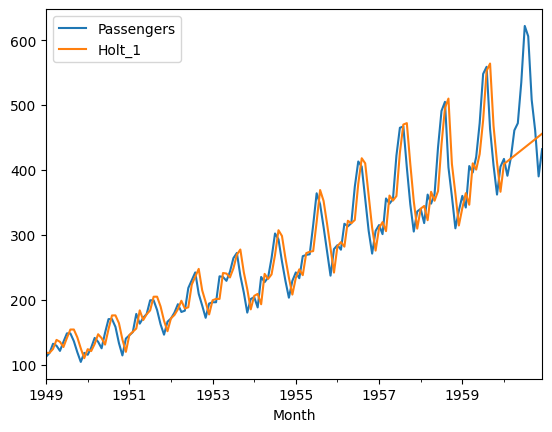

In [15]:
df[["Passengers", "Holt_1"]].plot()